<a href="https://colab.research.google.com/github/r-pranav-git/Deep-Learning-Workshop/blob/main/RNN_for_Movie_Review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Simple RNN for sentiment analysis with the IMDb Movie Review dataset

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from tensorflow.keras.datasets import imdb
vocab_size=10000
(X_train,y_train),(X_test,y_test)=imdb.load_data(num_words=vocab_size)
print("Training Samples:",len(X_train))
print("Testing Samples:",len(X_test))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Samples: 25000
Testing Samples: 25000


In [3]:
print(X_train[0])
print("Sentiment:",y_train[0])

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]
Sentiment: 1


In [4]:
word_index=imdb.get_word_index()
reverse_word_index={
    value + 3: key
    for key,value in word_index.items()

}
reverse_word_index[0]="<PAD>"
reverse_word_index[1]="<START>"
reverse_word_index[2]="<UNK>"
reverse_word_index[3]="<UNUSED>"

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
decoded_review=" ".join(
  reverse_word_index.get(i,"?")
  for i in X_train[0]
)
print(decoded_review)

<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <UNK> to the two little boy's that played the <UNK> of norman and paul they were just brilliant children are often left out of the <UNK> list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for wha

In [5]:
print(word_index["movie"])
print(word_index["bad"])

17
75


In [8]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_length=200
X_train=pad_sequences(
    X_train,
    maxlen=max_length
)
X_test=pad_sequences(
    X_test,
    maxlen=max_length
)
print(X_train.shape)

(25000, 200)


In [12]:
model=tf.keras.Sequential([
    tf.keras.layers.Embedding(
        input_dim=vocab_size,
        output_dim=32,
        input_length=max_length
    ),
    tf.keras.layers.SimpleRNN(32),

    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [14]:
history=model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 53ms/step - accuracy: 0.7005 - loss: 0.5650 - val_accuracy: 0.7902 - val_loss: 0.4618
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 50ms/step - accuracy: 0.8626 - loss: 0.3326 - val_accuracy: 0.8418 - val_loss: 0.3735
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.8972 - loss: 0.2620 - val_accuracy: 0.8368 - val_loss: 0.3964
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.9546 - loss: 0.1282 - val_accuracy: 0.8334 - val_loss: 0.4368
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 53ms/step - accuracy: 0.9687 - loss: 0.0897 - val_accuracy: 0.8218 - val_loss: 0.5139


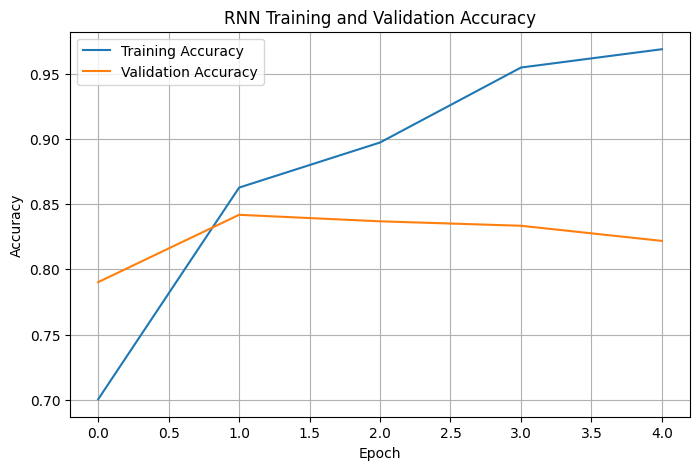

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("RNN Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [15]:
loss,accuracy=model.evaluate(
    X_test,
    y_test
)
print("Test Accuracy :",accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8206 - loss: 0.5088
Test Accuracy : 0.8206400275230408


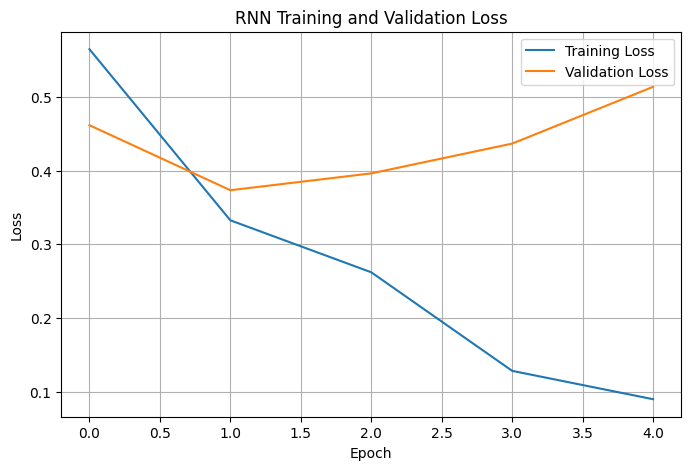

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RNN Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [18]:
prediction=model.predict(X_test[:5])
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step
[[9.0731581e-04]
 [9.9151045e-01]
 [7.4439150e-01]
 [2.1706174e-01]
 [9.7500676e-01]]


In [19]:
for i in range(5):
  if prediction[i]>0.5:
    print("Positive Review")
  else:
    print("Negative Review")

Negative Review
Positive Review
Positive Review
Negative Review
Positive Review
